# 课题：黑市九红的预期概率是多少？

# 背景

前段时间跟着这两个视频搞九红

![](img/Snipaste_2025-04-20_08-10-02.png)

反复SL了很久才刷出来，一边观察了黑市给的5个策略的规律，一边思考获得策略究竟是什么样的规律。

# 研究方式

```mermaid
graph LR
    A([提出猜想]) --> B([设计策略组])
    B --> C([录屏、OCR、清理数据])
    C --> D([分析数据、验证猜想])
    D --> A
```

# 录屏50小时以上，17724条记录，论文编写一周

![](img/Snipaste_2025-04-20_08-40-55.png)

# 爆肝，科研和写作均投入巨大精力，求三连！求三连！求三连！

In [1]:
import random
import utils

print("数据示例")
_, strategies = utils.parse_file("data/黑市房/黑市_全空.txt")
for rec in random.sample(strategies, 10):
    print(rec)

数据示例
[传承技火环[火_火环], 技能毒环[毒_中毒], 普攻寒冷[冰_寒冷], 中毒毒弹[毒_毒弹], 双发火环[火_火环]]
[环绕电球[电_电球], 持久电球[电_电球], 传承技冰锥[冰_冰锥], 冲刺燃烧[火_燃烧], 持久燃烧[火_燃烧]]
[普攻毒雾[毒_中毒], 技能闪电[电_闪电链], 冲刺毒弹[毒_毒弹], 传承技感电[电_感电], 脉冲强化[电_感电]]
[火精灵助战[火_火精灵], 冲刺落雷[电_落雷], 落雷光枪[光_光枪], 传承技风暴[刃_刀刃风暴], 召唤冰刺[冰_冰刺]]
[圣光标记[光_圣光标记], 随机标记[光_圣光标记], 技能感电[电_感电], 普攻寒冷[冰_寒冷], 电闪雷鸣[电_闪电链]]
[冲刺飞剑[刃_飞剑], 长距飞剑[刃_飞剑], 多重飞剑[刃_飞剑], 技能毒液[毒_毒液], 召唤刃环[刃_刃环]]
[放置地雷[火_地雷], 技能寒冷[冰_寒冷], 传承技火环[火_火环], 普攻燃烧[火_燃烧], 高效布雷[火_地雷]]
[技能风暴[刃_刀刃风暴], 风暴加速[刃_刀刃风暴], 放置地雷[火_地雷], 冲刺冰锥[冰_冰锥], 普攻寒冷[冰_寒冷]]
[技能感电[电_感电], 冲刺影子[暗_影子], 影子穿刺[暗_影刺], 普攻闪电[电_闪电链], 传承技风暴[刃_刀刃风暴]]
[普攻毒雾[毒_中毒], 冲刺影子[暗_影子], 技能火弹[火_火弹], 影刃冲刺[暗_影子], 火弹闪光[光_闪光]]


# 本视频从4月初开始构思，但官方在<font color='red '> 4月25日 </font> 更新到1.0.7大版本，测试数据来源于1.0.6版本（艾希联动版本），稍微体验新版本后，认为区别不大。

# 术语

![](img/概念说明图.jpg)

- **基础策略**：触发位可获得的第一个策略，例如：技能光枪。
- **一阶强化**：在获得**基础策略**后，可对其进行强化，通常是三选一，例如：光枪强化、圣光光枪、光枪禁锢。
- **二阶强化**：在获得**一阶强化**后，可对其进一步强化，例如：多重光枪。
- **双重策略**（也叫**红策略**）：在获得**二阶强化**和**红策略**要求的另一个**策略**后，可获得**双重策略**，例如：多重光枪+冲刺落雷=落雷光枪。
- **策略池**：获得一个新的策略时，全部可选的策略组成的集合。

# 定性分析

## 策略全空时，5个触发位的基础策略加入策略池

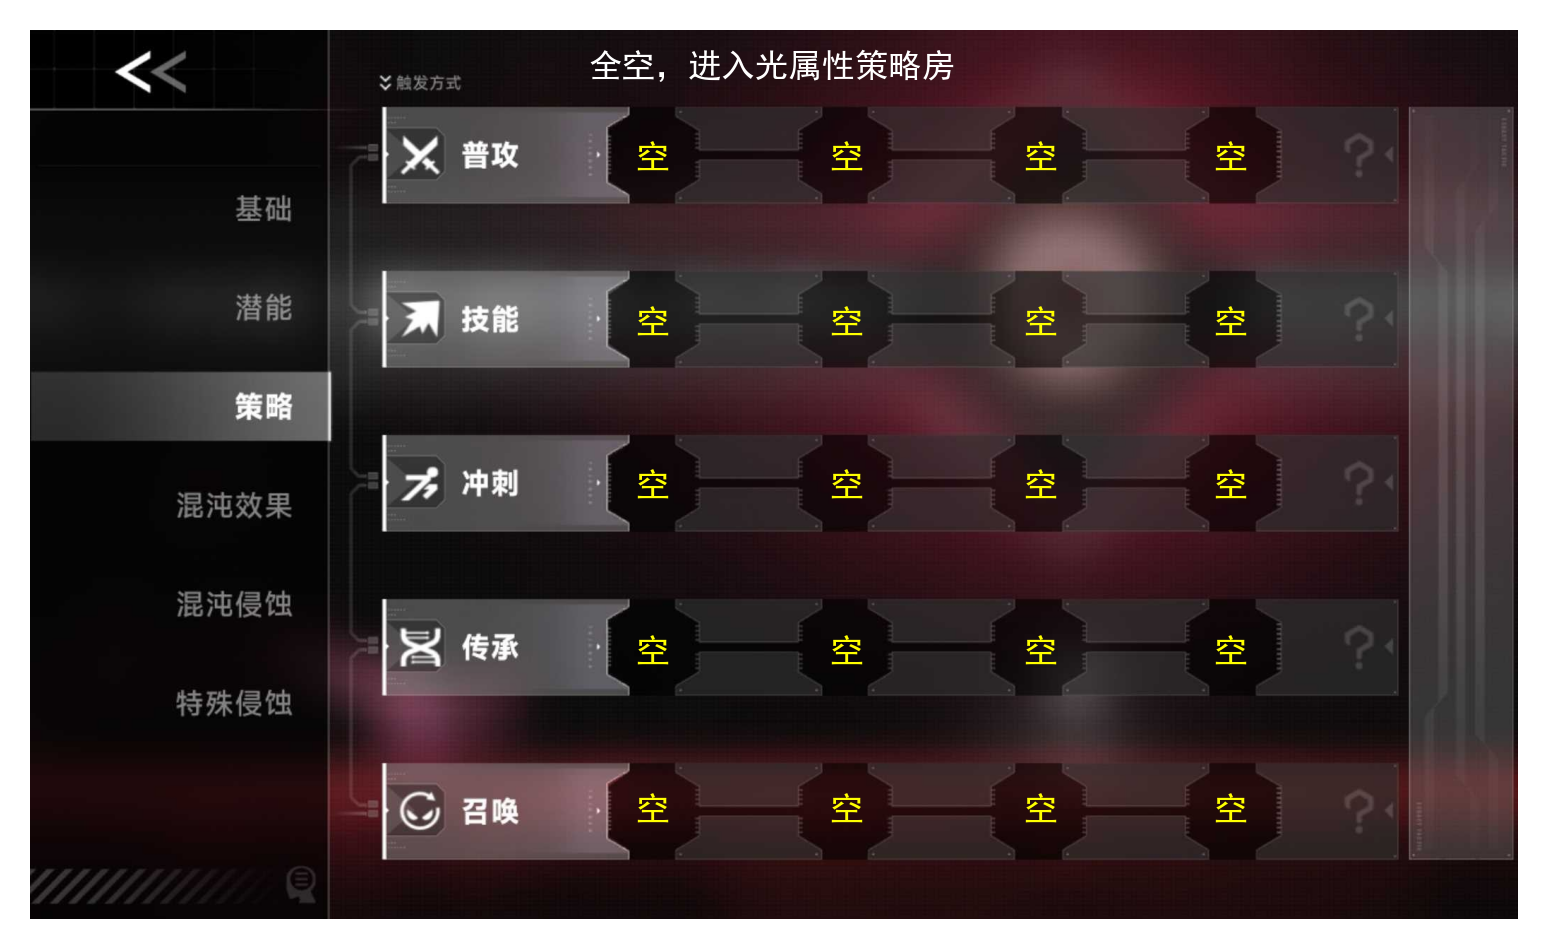

In [2]:
import utils

utils.draw_status('全空，进入光属性策略房', [['空'] * 4] * 5)

策略池内容：

1. 普攻光波
2. 技能光枪
3. 圣光标记
4. 传承技光枪
5. 传承技闪光
6. 召唤光阵

## 获得基础策略后，对应的一阶强化加入策略池，对应同名基础策略移除出策略池

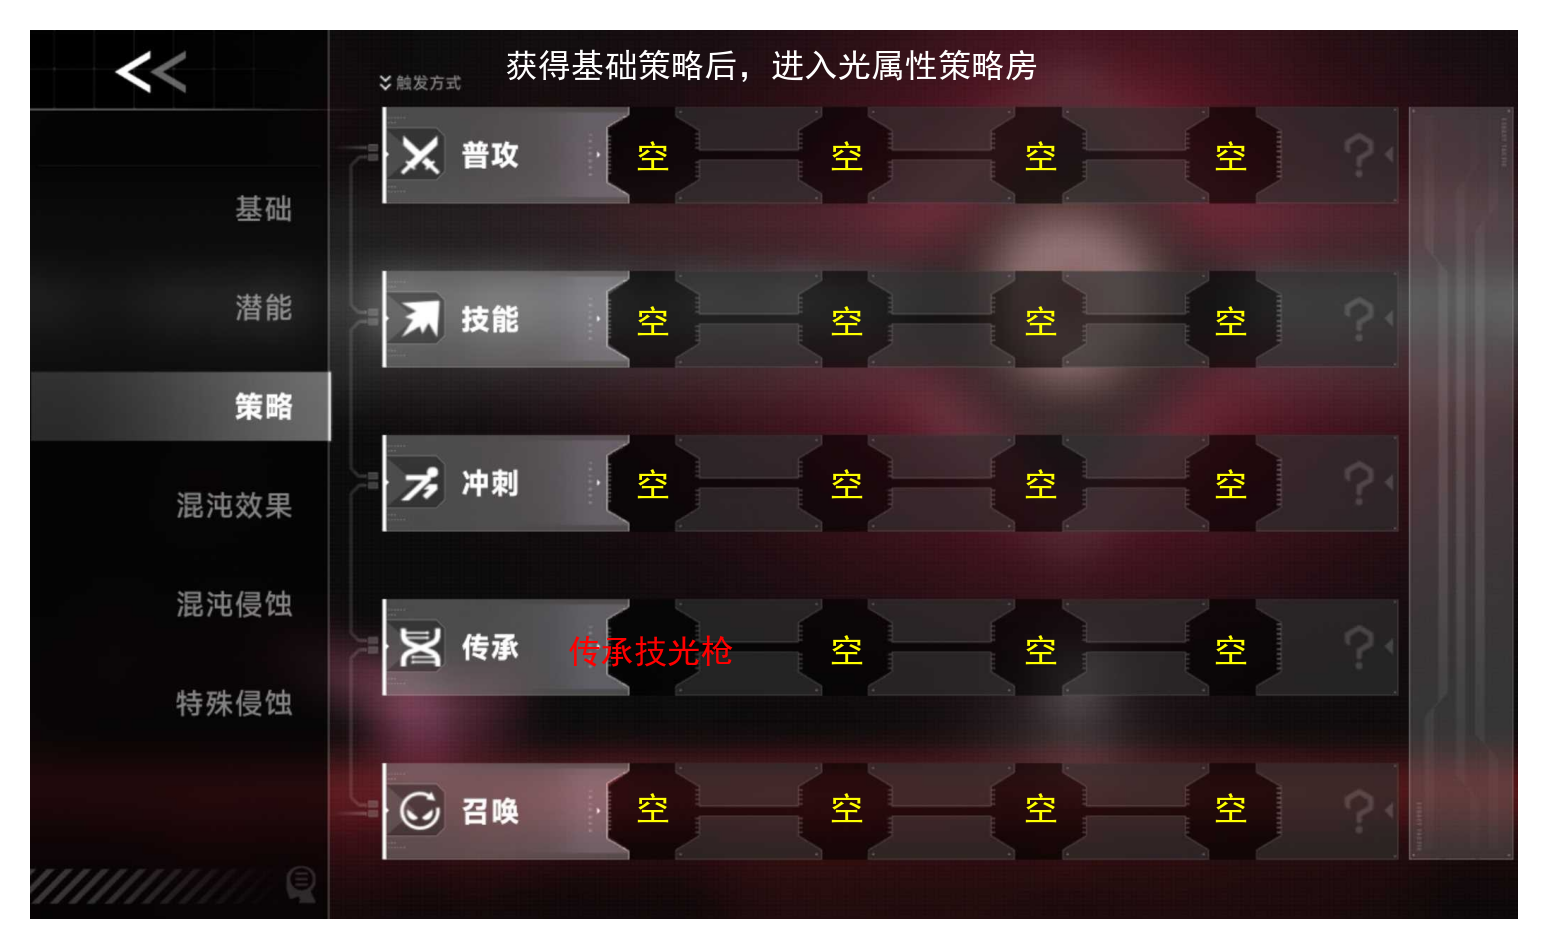

In [3]:
utils.draw_status('获得基础策略后，进入光属性策略房',
                  [['空'] * 4, ['空'] * 4, ['空'] * 4, ['传承技光枪', '空', '空', '空'], ['空'] * 4, ])

策略池内容：
1. 普攻光波
2. ~~技能光枪~~（已获得同名基础策略）
3. 圣光标记
4. ~~传承技光枪~~（已获得）
5. 传承技闪光（可替换）
6. 召唤光阵
7. 光枪一阶强化
    1. 圣光光枪
    2. 光枪禁锢
    3. 光枪强化

## 获得一阶强化后，对应的二阶强化加入策略池，替换策略移除出策略池

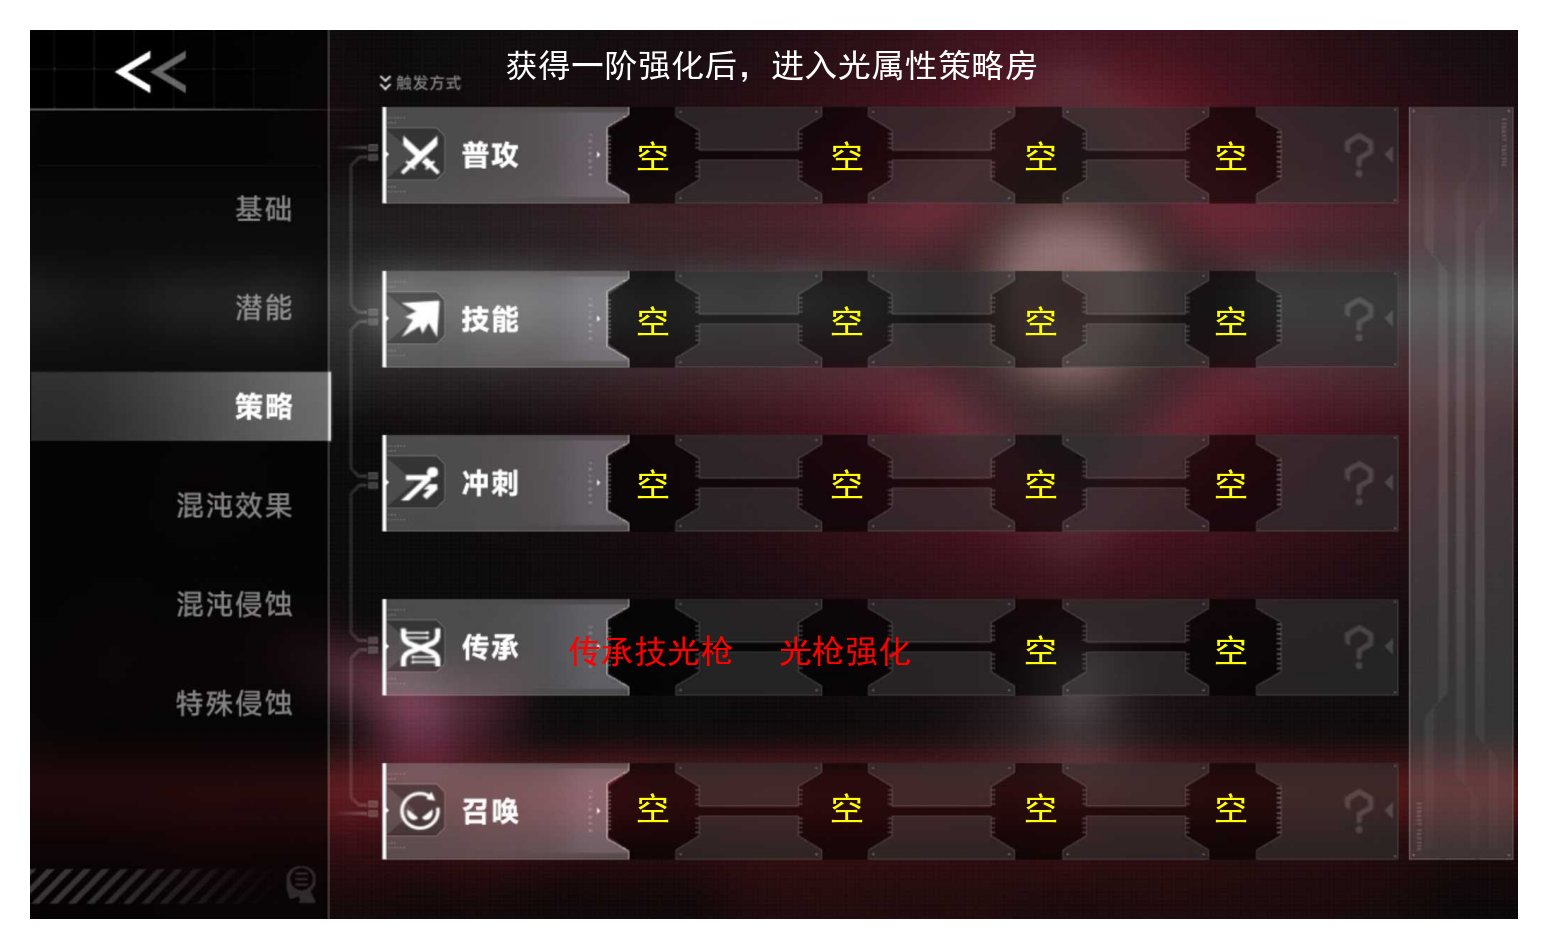

In [4]:
utils.draw_status('获得一阶强化后，进入光属性策略房',
                  [['空'] * 4, ['空'] * 4, ['空'] * 4, ['传承技光枪', '光枪强化', '空', '空'], ['空'] * 4, ])

策略池内容：
1. 普攻光波
2. ~~技能光枪~~（已获得同名基础策略）
3. 圣光标记
4. ~~传承技光枪~~（已获得）
5. ~~传承技闪光~~（传承位已有强化，无法替换）
6. 召唤光阵
7. ~~光枪一阶强化~~（已获得）
    1. ~~圣光光枪~~
    2. ~~光枪禁锢~~
    3. ~~光枪强化~~
8. 光枪二阶强化
    1. 多重光枪

> **注**：只要基础策略所在的行拥有 一阶/二阶/双重 策略，该基础策略将变得 **不可被替换**

## 获得二阶强化后，且拥有红策略依赖的另一个策略，对应的红策略加入策略池

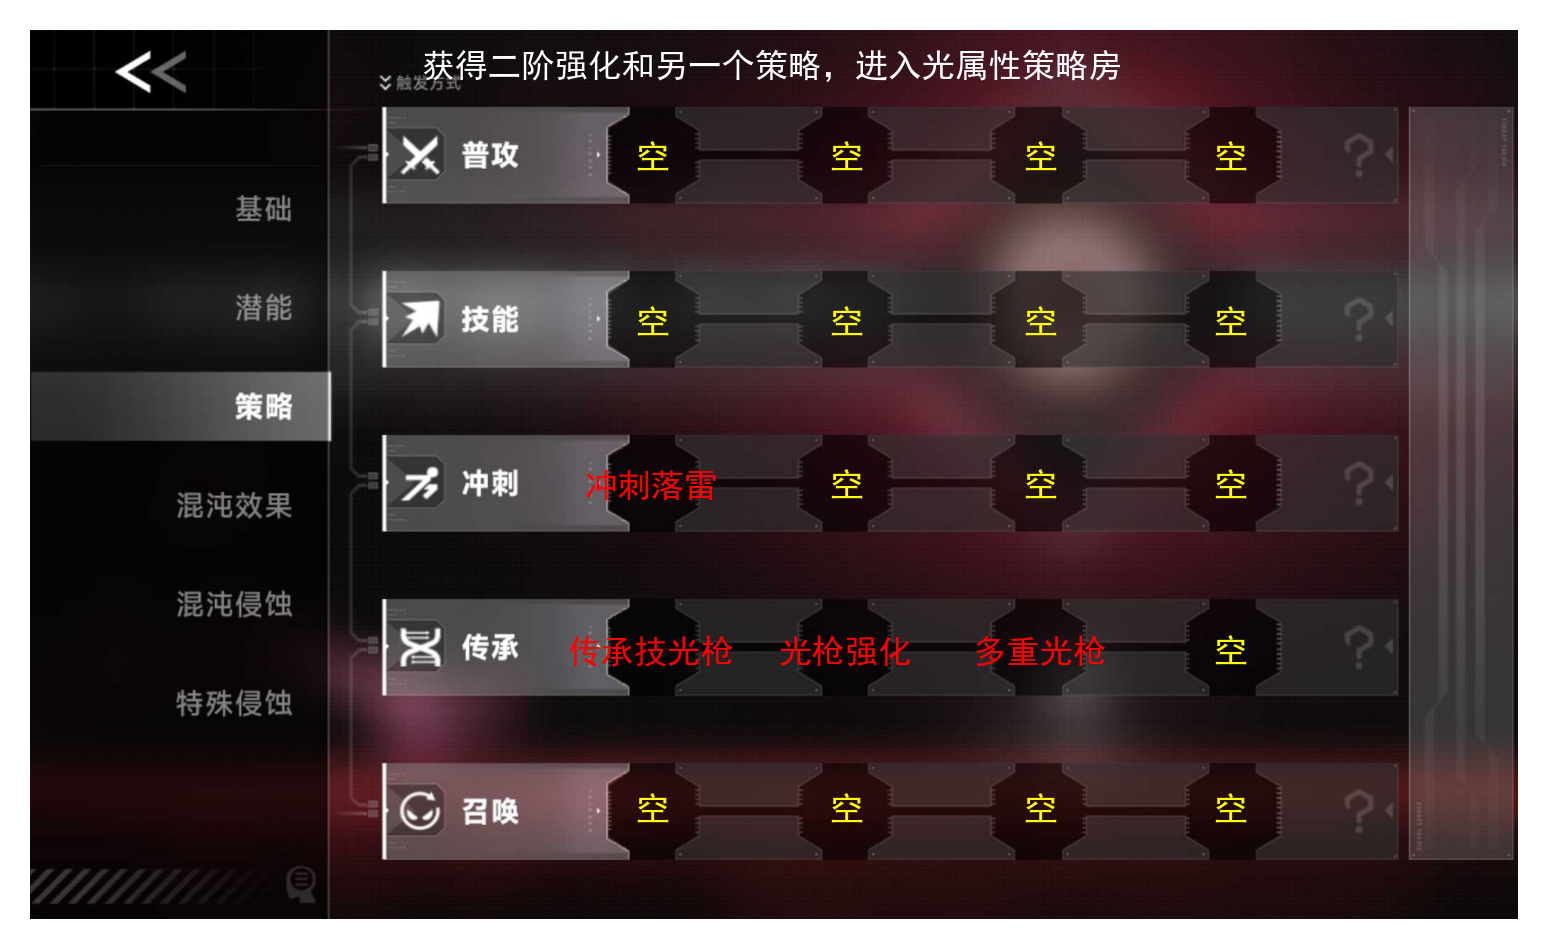

In [5]:
utils.draw_status('获得二阶强化和另一个策略，进入光属性策略房',
                  [['空'] * 4, ['空'] * 4, ['冲刺落雷', '空', '空', '空'], ['传承技光枪', '光枪强化', '多重光枪', '空'],
                   ['空'] * 4, ])

策略池内容：
1. 普攻光波
2. ~~技能光枪~~（已获得同名基础策略）
3. 圣光标记（可替换冲刺落雷）
4. ~~传承技光枪~~（已获得）
5. ~~传承技闪光~~（传承位已有强化，无法替换）
6. 召唤光阵
7. ~~光枪一阶强化~~（已获得）
    1. ~~圣光光枪~~
    2. ~~光枪禁锢~~
    3. ~~光枪强化~~
8. ~~光枪二阶强化~~（已获得）
     1. ~~多重光枪~~
9. 红策略：落雷光枪

# 获得红策略后，其依赖的二阶强化和基础策略将被锁定，不可被替换

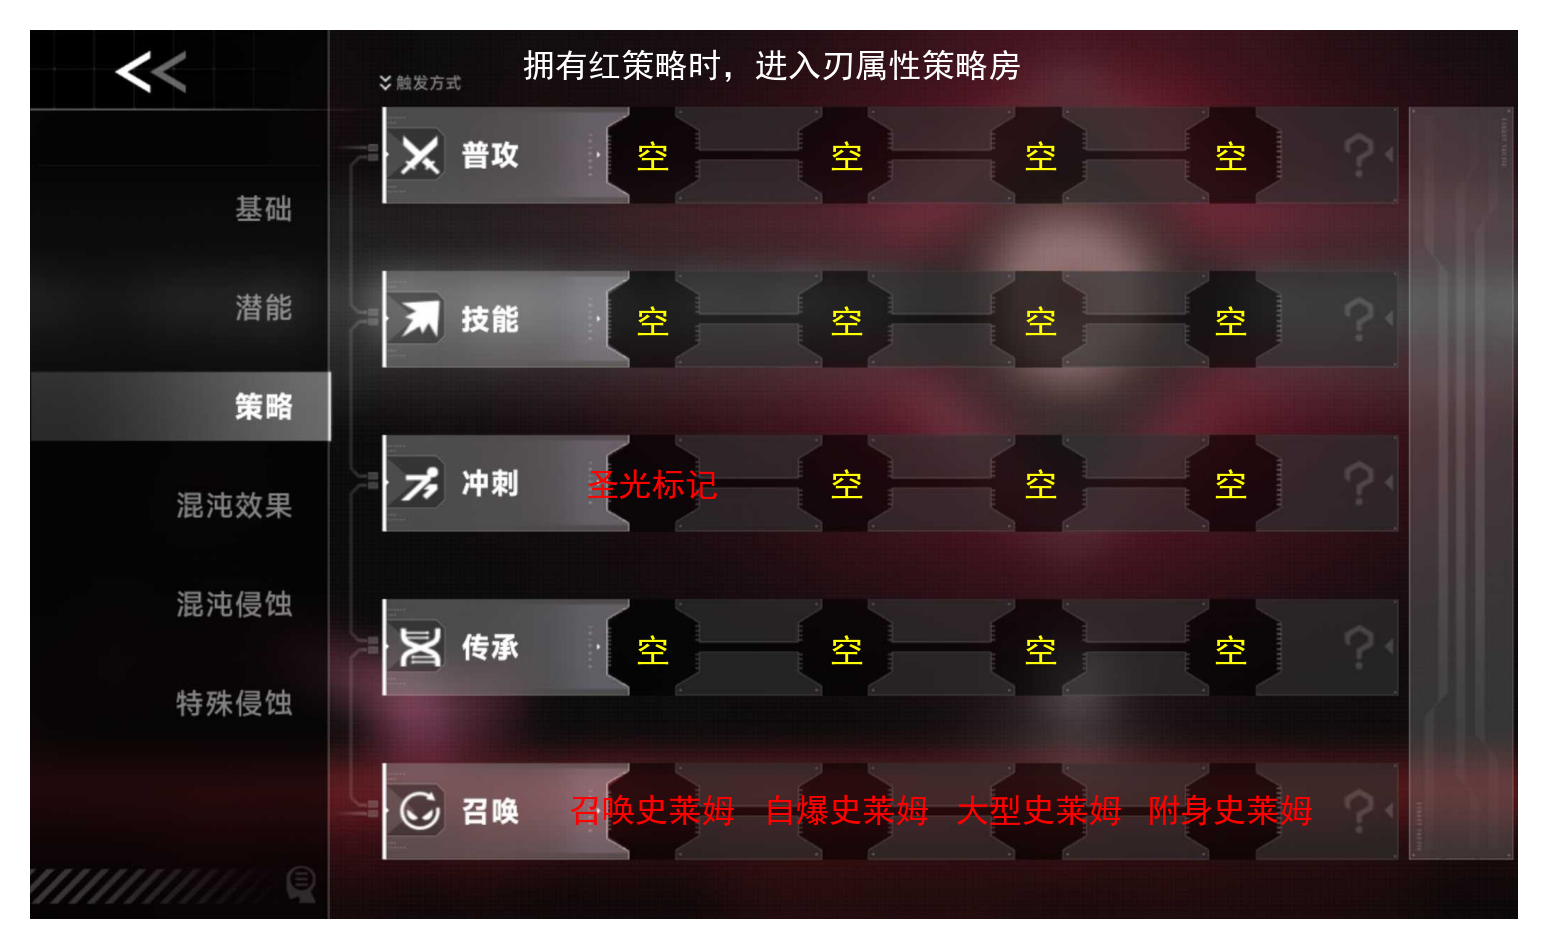

In [6]:
utils.draw_status('拥有红策略时，进入刃属性策略房', [['空'] * 4, ['空'] * 4, ['圣光标记', '空', '空', '空'], ['空'] * 4,
                                                    ['召唤史莱姆', '自爆史莱姆', '大型史莱姆', '附身史莱姆'], ])

策略池内容：

1. 普攻撕裂
2. 技能撕裂
3. 技能风暴
4. ~~冲刺飞剑~~（圣光标记因获得红策略被锁定，无法被替换）
5. 传承技风暴
6. ~~召唤刃环~~（召唤史莱姆占用）

## 特例：传承数据体的红策略不会锁定其依赖的基础策略。

例如：
- 传承1，\[召唤史莱姆\]，\[附身史莱姆\]
- 传承2，\[圣光标记\]

此时\[圣光标记\]是可以被替换的。

![](img/传承附身史莱姆.gif)

# 商店和高级战斗的策略池

商店购买策略和高级战斗获得的策略遵循相同的规律。

## 在策略房的基础上，不再约束策略池的属性

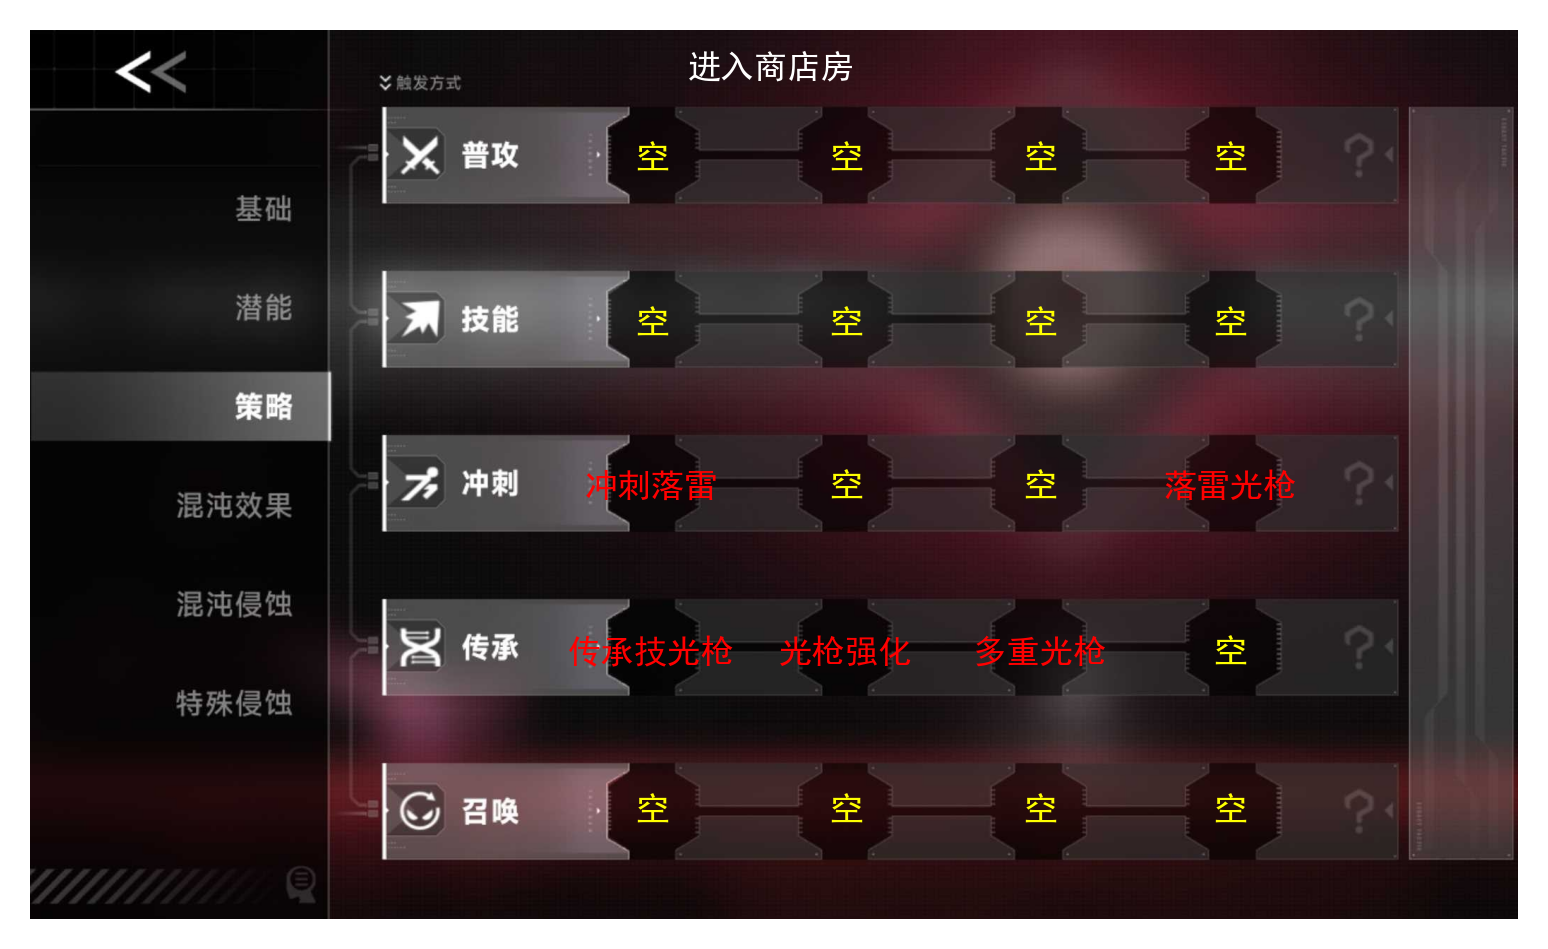

In [7]:
utils.draw_status('进入商店房', [['空'] * 4, ['空'] * 4, ['冲刺落雷', '空', '空', '落雷光枪'],
                                 ['传承技光枪', '光枪强化', '多重光枪', '空'], ['空'] * 4, ])

策略池内容：

1. 普攻位：普攻撕裂、普攻影刺、普攻闪电、普攻燃烧、火精灵助战、普攻寒冷、普攻光波、普攻毒雾
2. 技能位：技能撕裂、技能风暴、技能影刺、技能感电、技能闪电、技能燃烧、技能火弹、技能寒冷、~~技能光枪~~、技能毒环、技能毒液

（技能光枪除外，因为已获得传承技光枪）

3. 冲刺位：落雷一阶强化
    1. 受击落雷
    2. 闪避落雷
    3. 落雷强化
    4. 落雷麻痹
4. 传承位：已满
5. 召唤位：召唤刃环、召唤触手、环绕电球、放置地雷、召唤冰刺、召唤光阵、召唤史莱姆

# 黑市“随机获得5个策略”

> **注**：“随机获得5个策略”本质是“获得1个随机策略，重复5次”，因此下文只讨论“获得1个随机策略”的策略池。

## 策略全空时，5个触发位的全部基础策略加入策略池

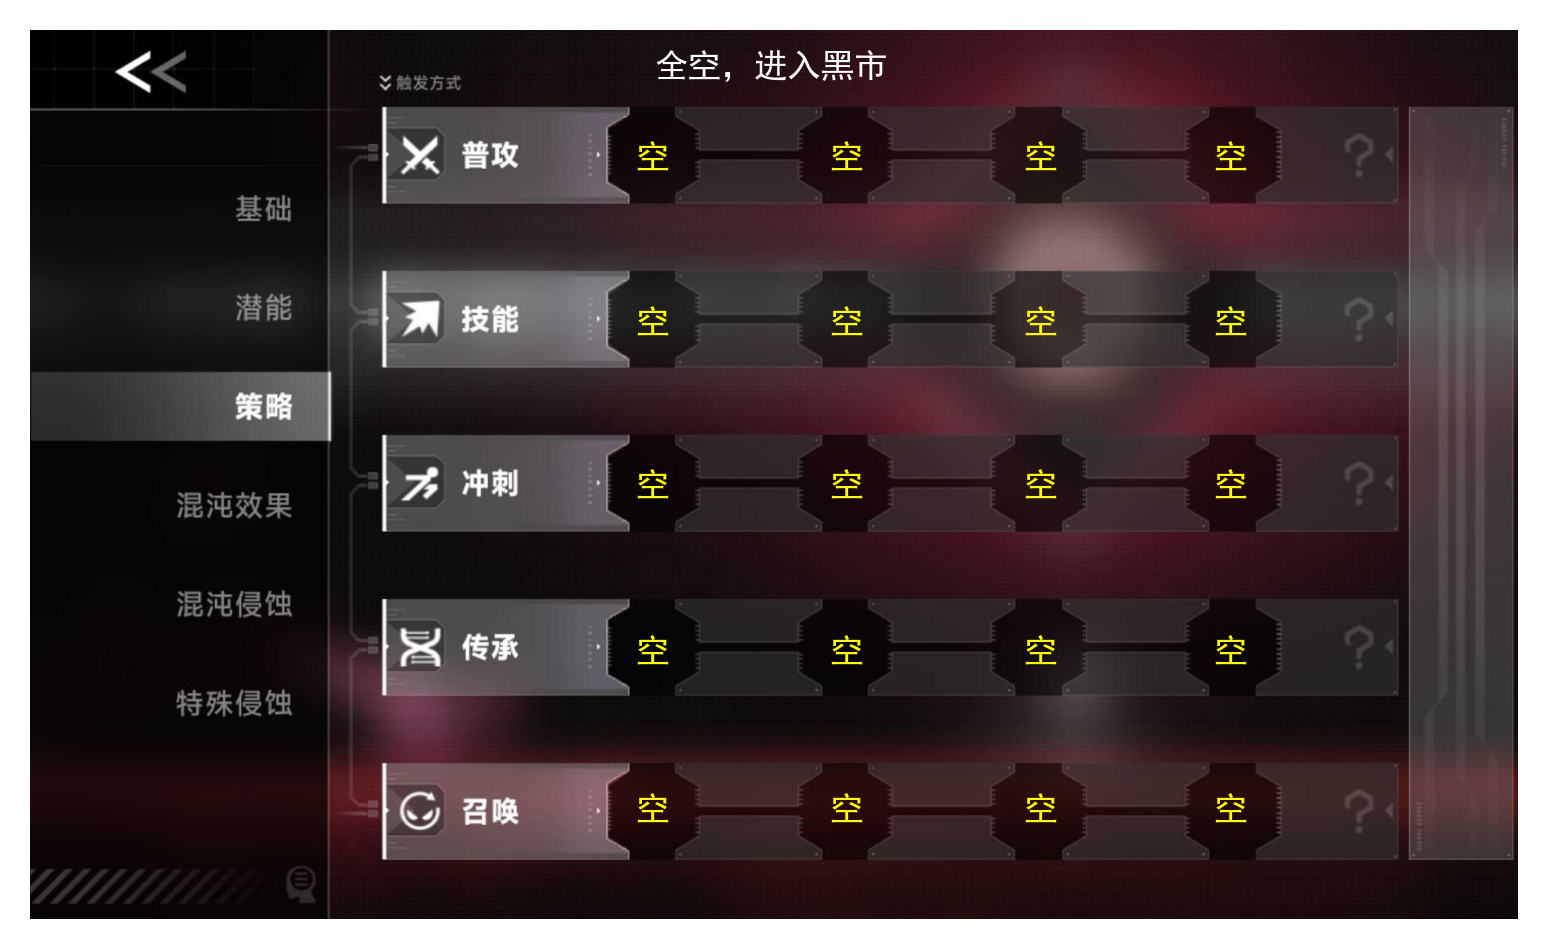

In [8]:
utils.draw_status('全空，进入黑市', [['空'] * 4] * 5)

策略池内容：

1. 普攻位：全部普攻基础策略
2. 技能位：全部技能基础策略
3. 冲刺位：全部冲刺基础策略
4. 传承位：全部传承技基础策略
5. 召唤位：全部召唤基础策略

## 拥有某系的基础策略时，其对应的全部一阶强化、二阶强化、单激活红策略加入策略池

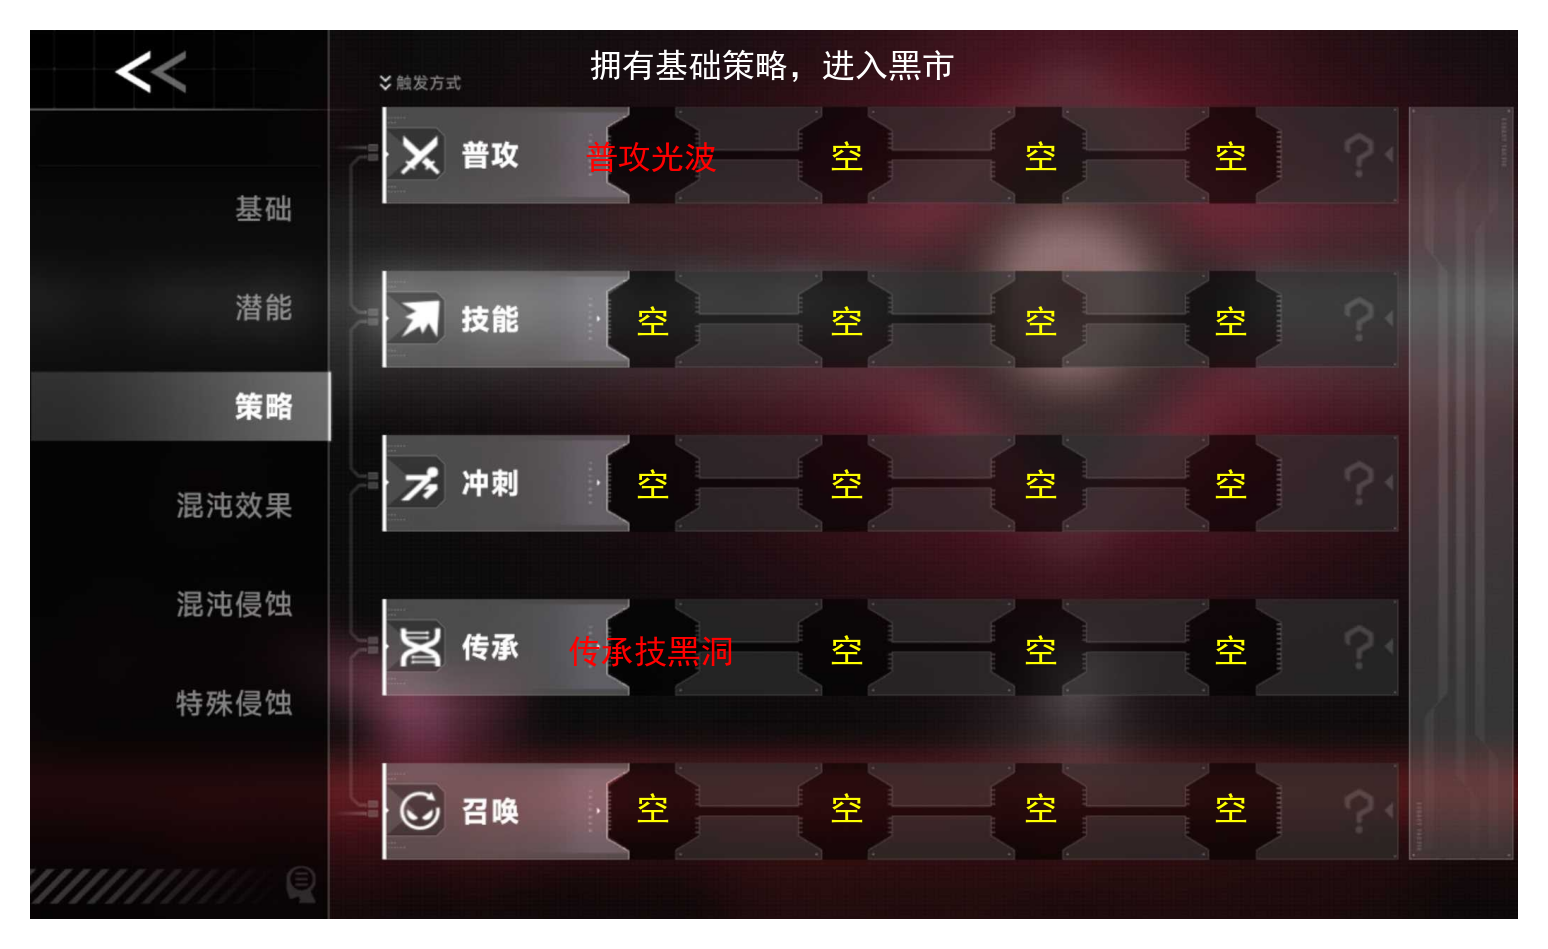

In [9]:
utils.draw_status('拥有基础策略，进入黑市',
                  [['普攻光波', '空', '空', '空'], ['空'] * 4, ['空'] * 4, ['传承技黑洞', '空', '空', '空'],
                   ['空'] * 4], )

策略池内容：
1. 普攻位：
    1. 一阶：光波强化，光波眩晕，灵活充能
    2. 二阶：增强光波
    3. 单激活红：光波传递
    4. 双激活红：依赖\[圣光标记\]和\[召唤光阵\]，未携带，不加入策略池。
2. 技能位：全部技能基础策略
3. 冲刺位：全部冲刺基础策略
4. 传承位：
    1. 一阶：大型黑洞，黑洞爆炸，持久黑洞
    2. 二阶：黑洞盛宴
    3. 单激活红：黑洞减速、黑洞脉冲、黑洞刀刃
5. 召唤位：全部召唤基础策略

## 拥有两个基础策略时，对应的双激活红策略加入策略池

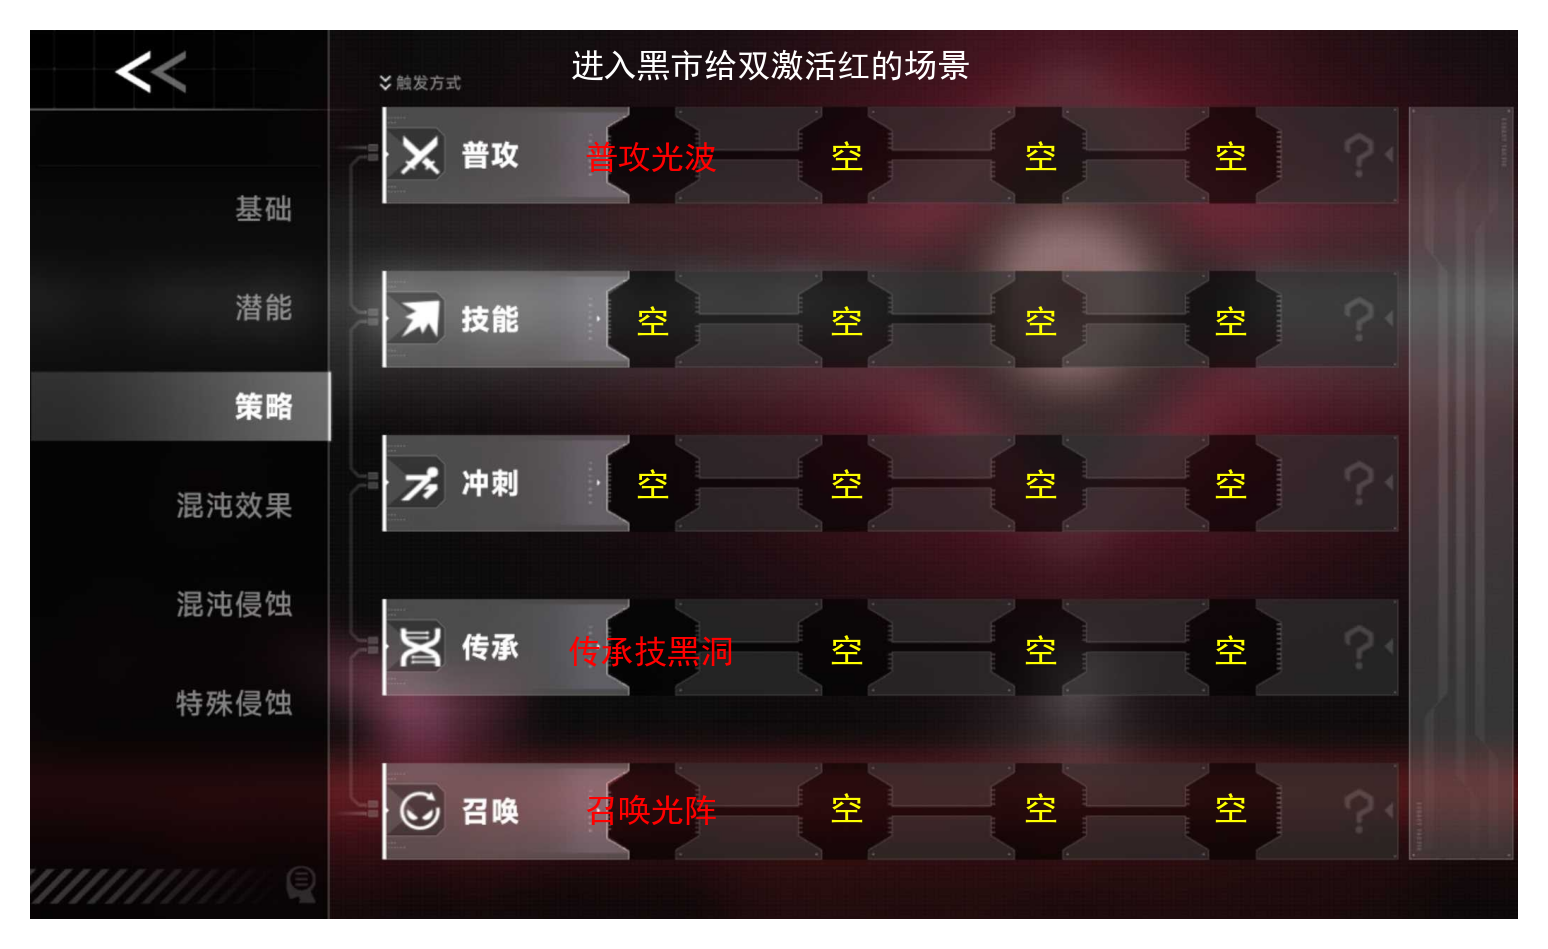

In [10]:
utils.draw_status('进入黑市给双激活红的场景',
                  [['普攻光波', '空', '空', '空'], ['空'] * 4, ['空'] * 4, ['传承技黑洞', '空', '空', '空'],
                   ['召唤光阵', '空', '空', '空']], )

策略池内容：
1. 普攻位：
    1. 一阶：光波强化，光波眩晕，灵活充能
    2. 二阶：增强光波
    3. 单激活红：光波传递
    4. 双激活红：
        1. 光波快充（有召唤光阵，所以可获得光波快充）
        2. ~~至圣标记~~（没有圣光标记，所以不可获得至圣标记）
2. 技能位：全部技能基础策略
3. 冲刺位：全部冲刺基础策略
4. 传承位：
    1. 一阶：大型黑洞，黑洞爆炸，持久黑洞
    2. 二阶：黑洞盛宴
    3. 单激活红：黑洞减速、黑洞脉冲、黑洞刀刃
5. 召唤位：
    1. 一阶：光阵致盲，光阵庇护，光阵增幅
    2. 二阶：大型光阵
    3. 单激活红：光阵吸引

### 例外1：寒冷系策略，获得一阶强化后，对应分支的二阶强化和红策略才会加入策略池

![](img/寒冷.jpg)

In [11]:
_, strategies = utils.parse_file("data/黑市房/黑市_寒冰史莱姆.txt")
ices = [[i for i in sub_arr if i.attribute == '冰'] for sub_arr in strategies]

for one_roll in ices:
    print(one_roll)
    print("策略等级", [x.level for x in one_roll])

[寒气爆发[冰_寒冷], 冰霜爆破[冰_寒冷]]
策略等级 [1, 2]
[聚寒成冰[冰_寒冷], 强力破冰[冰_寒冷]]
策略等级 [1, 2]
[寒气爆发[冰_寒冷], 冰霜爆破[冰_寒冷]]
策略等级 [1, 2]
[聚寒成冰[冰_寒冷], 冰冻冰锥[冰_冰锥]]
策略等级 [1, 3]
[聚寒成冰[冰_寒冷], 强力破冰[冰_寒冷], 冰冻冰锥[冰_冰锥]]
策略等级 [1, 2, 3]
[聚寒成冰[冰_寒冷], 强力破冰[冰_寒冷], 冰冻冰锥[冰_冰锥]]
策略等级 [1, 2, 3]
[寒气爆发[冰_寒冷], 冰霜爆破[冰_寒冷]]
策略等级 [1, 2]
[寒气爆发[冰_寒冷], 冰霜爆破[冰_寒冷]]
策略等级 [1, 2]
[聚寒成冰[冰_寒冷], 冰冻冰锥[冰_冰锥]]
策略等级 [1, 3]
[聚寒成冰[冰_寒冷], 冰冻冰锥[冰_冰锥]]
策略等级 [1, 3]
[聚寒成冰[冰_寒冷], 冰冻冰锥[冰_冰锥]]
策略等级 [1, 3]
[聚寒成冰[冰_寒冷], 强力破冰[冰_寒冷]]
策略等级 [1, 2]
[聚寒成冰[冰_寒冷], 强力破冰[冰_寒冷]]
策略等级 [1, 2]
[聚寒成冰[冰_寒冷], 强力破冰[冰_寒冷], 冰冻冰锥[冰_冰锥]]
策略等级 [1, 2, 3]
[聚寒成冰[冰_寒冷], 冰冻冰锥[冰_冰锥]]
策略等级 [1, 3]
[聚寒成冰[冰_寒冷], 强力破冰[冰_寒冷]]
策略等级 [1, 2]
[寒气爆发[冰_寒冷], 冰霜脉冲[冰_寒冷], 冰霜爆破[冰_寒冷]]
策略等级 [1, 3, 2]


### 例外2：史莱姆系策略，获得一阶强化或二阶强化后，后续获得的新策略不会与已有分支产生冲突

![](img/史莱姆.jpg)

In [12]:
slimes = [[i for i in sub_arr if i.attribute == '毒'] for sub_arr in strategies]

for one_roll in slimes:
    print(one_roll)
for one_roll in slimes:
    # Line1: 自爆史莱姆 -> 大型史莱姆
    # Line2：长效史莱姆 -> 极速史莱姆
    if any(x for x in one_roll if x.name in ['自爆史莱姆', '大型史莱姆']) and any(
            x for x in one_roll if x.name in ['长效史莱姆', '极速史莱姆']):
        print("检查到冲突")
    else:
        print("未检查到冲突")

[结队史莱姆[毒_史莱姆], 自爆史莱姆[毒_史莱姆], 大型史莱姆[毒_史莱姆]]
[附身史莱姆[毒_史莱姆], 自爆史莱姆[毒_史莱姆], 大型史莱姆[毒_史莱姆]]
[剧毒史莱姆[毒_中毒], 长效史莱姆[毒_史莱姆], 极速史莱姆[毒_史莱姆]]
[附身史莱姆[毒_史莱姆], 长效史莱姆[毒_史莱姆], 极速史莱姆[毒_史莱姆]]
[长效史莱姆[毒_史莱姆], 分裂史莱姆[毒_史莱姆]]
[附身史莱姆[毒_史莱姆], 自爆史莱姆[毒_史莱姆]]
[剧毒史莱姆[毒_中毒], 自爆史莱姆[毒_史莱姆], 大型史莱姆[毒_史莱姆]]
[剧毒史莱姆[毒_中毒], 自爆史莱姆[毒_史莱姆], 大型史莱姆[毒_史莱姆]]
[剧毒史莱姆[毒_中毒], 长效史莱姆[毒_史莱姆], 极速史莱姆[毒_史莱姆]]
[附身史莱姆[毒_史莱姆], 自爆史莱姆[毒_史莱姆], 大型史莱姆[毒_史莱姆]]
[剧毒史莱姆[毒_中毒], 自爆史莱姆[毒_史莱姆], 大型史莱姆[毒_史莱姆]]
[分裂史莱姆[毒_史莱姆], 长效史莱姆[毒_史莱姆], 极速史莱姆[毒_史莱姆]]
[分裂史莱姆[毒_史莱姆], 长效史莱姆[毒_史莱姆], 极速史莱姆[毒_史莱姆]]
[剧毒史莱姆[毒_中毒], 长效史莱姆[毒_史莱姆]]
[分裂史莱姆[毒_史莱姆], 长效史莱姆[毒_史莱姆], 极速史莱姆[毒_史莱姆]]
[自爆史莱姆[毒_史莱姆], 大型史莱姆[毒_史莱姆], 附身史莱姆[毒_史莱姆]]
[长效史莱姆[毒_史莱姆], 附身史莱姆[毒_史莱姆]]
未检查到冲突
未检查到冲突
未检查到冲突
未检查到冲突
未检查到冲突
未检查到冲突
未检查到冲突
未检查到冲突
未检查到冲突
未检查到冲突
未检查到冲突
未检查到冲突
未检查到冲突
未检查到冲突
未检查到冲突
未检查到冲突
未检查到冲突


## 已存在策略的位置，黑市不会在给该位置生成策略

例如一阶强化：已拥有\[光波强化\]（光波系一阶强化），则黑市不会生成\[光波眩晕\]和\[灵活充能\]

例如红策略：已拥有\[光波传递\]（光波系普攻位红策略），则黑市不会生成\[至圣标记\]和\[光波快充\]

## 例外：雷云火弹和中毒毒弹不占用位置，不受本条规则约束

例如：已有\[雷云火弹\]，黑市仍然可以获取 \[闪电感电\]或者\[电解化毒\]。反之亦然。

例如：已有\[中毒毒弹\]，黑市仍然可以获得\[连续刃环\]或者\[寒冰毒雾\]。反之亦然。

再次强调：<font color='red'>雷云火弹和中毒毒弹不占用位置</font>！在 策略房、商店房、黑市房 均不占用位置！

## 如果没有符合要求的策略，则黑市无法获得新策略

例如：全满时进入黑市，黑市会给0个策略。

例如：带有3个空槽，黑市只会给3个策略。

## 由于黑市是获得1个随机策略，重复5次，因此每次获得的策略均会对后续的策略池产生影响

# 定量分析

在上文的基础上，各个策略在池内的分布具体是怎样的？它们的获得概率是相等的吗？

接下来，将分为三个部分详细介绍，通过概率论和数理统计的方式推测概率，对黑市进行数学建模，最终给出黑市九红不同方案的最高概率。